<Axes: title={'center': 'Normal (0) vs Flagged (1) Invoices'}, xlabel='flag_invoice'>

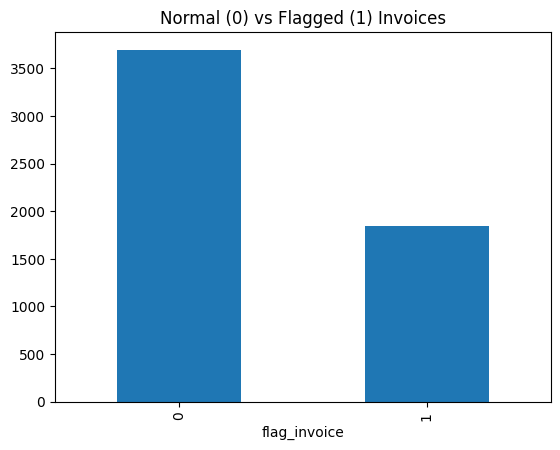

In [5]:
import sqlite3
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

conn = sqlite3.connect('C:/Users/D E L L/Desktop/CODING/vendor_invoice_intelligence/data/inventory.db')

# Execute the complex join query from our previous step
query = """
SELECT 
    p.PONumber as po_number,   -- Changed this!
    COUNT(DISTINCT p.Brand) as total_brands,
    SUM(p.Quantity) as total_item_quantity,
    SUM(p.Dollars) as total_item_dollars,
    AVG(julianday(p.ReceivingDate) - julianday(p.PODate)) as avg_receiving_delay
FROM purchases p
GROUP BY p.PONumber;          
"""
purchase_df = pd.read_sql_query(query, conn)

vi_query = "SELECT PONumber as po_number, Quantity as invoice_quantity, Dollars as invoice_dollars, Freight as freight_cost FROM vendor_invoice;"
vi_df = pd.read_sql_query(vi_query, conn)

final_df = pd.merge(purchase_df, vi_df, on='po_number', how='left').dropna()

# Create Label
final_df['flag_invoice'] = np.where(
    (final_df['total_item_quantity'] != final_df['invoice_quantity']) | 
    (final_df['avg_receiving_delay'] > 10), 1, 0
)
final_df['flag_invoice'].value_counts().plot(kind='bar', title="Normal (0) vs Flagged (1) Invoices")


In [6]:
# Separate into two groups
flagged = final_df[final_df['flag_invoice'] == 1]
normal = final_df[final_df['flag_invoice'] == 0]

metrics_to_test = ['total_brands', 'total_item_quantity', 'total_item_dollars', 'avg_receiving_delay', 'invoice_quantity', 'invoice_dollars', 'freight_cost']

significant_features = []
non_significant_features = []

print("--- T-Test Results ---")
for metric in metrics_to_test:
    stat, p_value = ttest_ind(flagged[metric], normal[metric], equal_var=False)
    
    if p_value < 0.05:
        significant_features.append(metric)
    else:
        non_significant_features.append(metric)
        
print("Significant Features (Keep these):", significant_features)
print("Non-Significant Features (Drop these):", non_significant_features)

--- T-Test Results ---
Significant Features (Keep these): ['total_item_quantity', 'total_item_dollars', 'avg_receiving_delay', 'invoice_quantity', 'invoice_dollars', 'freight_cost']
Non-Significant Features (Drop these): ['total_brands']


In [7]:
# Use only significant features
X = final_df[['total_item_quantity', 'total_item_dollars', 'invoice_quantity', 'invoice_dollars']]
y = final_df['flag_invoice']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

models = {
    "Logistic Regression": LogisticRegression(),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42)
}

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    preds = model.predict(X_test_scaled)
    acc = accuracy_score(y_test, preds)
    f1 = f1_score(y_test, preds)
    print(f"{name} -> Accuracy: {acc:.2f} | F1 Score: {f1:.2f}")

Logistic Regression -> Accuracy: 0.64 | F1 Score: 0.01
Decision Tree -> Accuracy: 0.83 | F1 Score: 0.75
Random Forest -> Accuracy: 0.87 | F1 Score: 0.80


Fitting 5 folds for each of 72 candidates, totalling 360 fits
Best Parameters: {'criterion': 'gini', 'max_depth': None, 'min_samples_split': 5, 'n_estimators': 200}
Tuned Accuracy: 0.8846


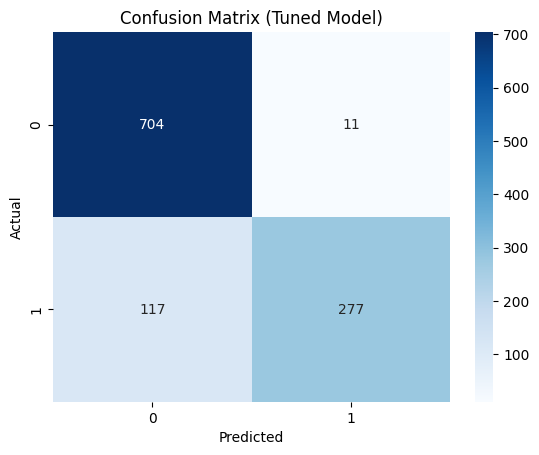

In [8]:
# The creator used GridSearch to squeeze out an extra 2% accuracy
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 4, 5, 6],
    'min_samples_split': [2, 3, 5],
    'criterion': ['gini', 'entropy']
}

rf = RandomForestClassifier(random_state=42)
grid_search = GridSearchCV(estimator=rf, param_grid=param_grid, scoring='f1', cv=5, n_jobs=-1, verbose=2)
grid_search.fit(X_train_scaled, y_train)

print(f"Best Parameters: {grid_search.best_params_}")

# Evaluate best model
best_model = grid_search.best_estimator_
preds = best_model.predict(X_test_scaled)
print(f"Tuned Accuracy: {accuracy_score(y_test, preds):.4f}")

# Confusion Matrix
cm = confusion_matrix(y_test, preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix (Tuned Model)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()